# Load the data and split it

In [2]:
import get_data as data
import matplotlib.pyplot as plt
from keras import layers, models
from sklearn.metrics import confusion_matrix

image_size = (64, 64)

(train_images, test_images, label_names) = data.get_data(image_size)

print("Number of training batches: ", len(train_images))
print("Number of testing batches: ", len(test_images))
print("Class names: ", label_names)

Found 75000 files belonging to 5 classes.
Using 52500 files for training.
Using 22500 files for validation.
Number of training batches:  410
Number of testing batches:  176
Class names:  ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

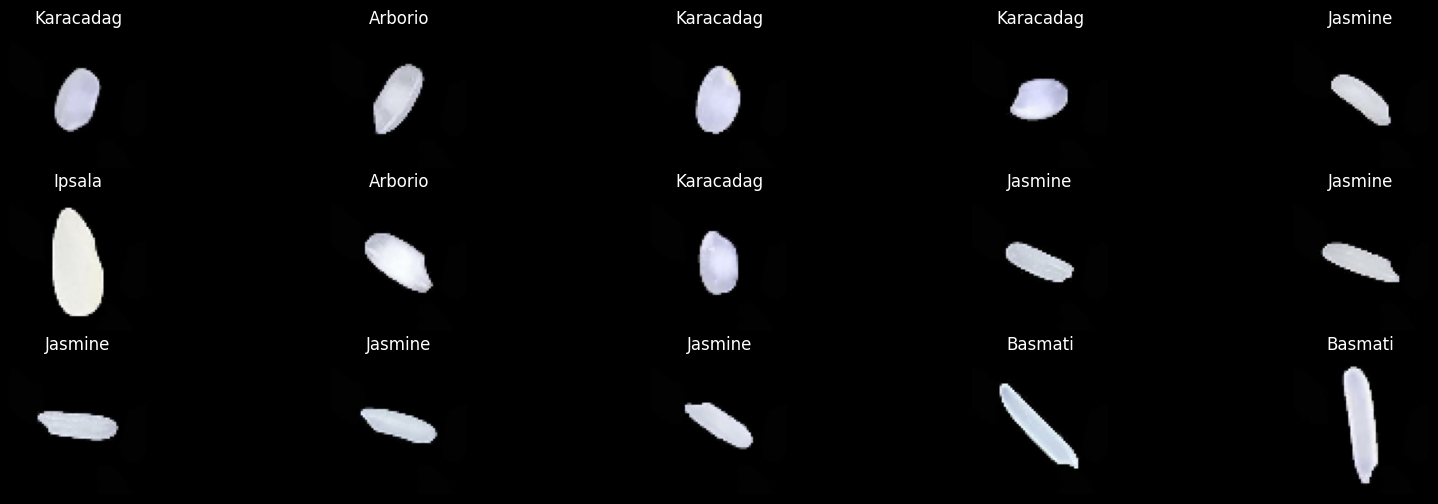

In [3]:
plt.figure(figsize=(20,6))

for images, labels in train_images.take(1):
    for i in range(15):
        plt.subplot(3,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(label_names[labels[i]])
        plt.axis("off")

plt.show()

In [4]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(8, (3,3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973 (7.71 KB)

 Trainable params: 1,973 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [6]:
history = model.fit(train_images, epochs=25, validation_data=test_images)

Epoch 1/25
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.5042 - loss: 7.7616 - val_accuracy: 0.6570 - val_loss: 1.0683
Epoch 2/25
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.7493 - loss: 0.7153 - val_accuracy: 0.8068 - val_loss: 0.5596
Epoch 3/25
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8253 - loss: 0.4869 - val_accuracy: 0.8556 - val_loss: 0.4003
Epoch 4/25
410/410 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8677 - loss: 0.3667 - val_accuracy: 0.8864 - val_loss: 0.3232
Epoch 5/25
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.8893 - loss: 0.3059 - val_accuracy: 0.9078 - val_loss: 0.2508
Epoch 6/25
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8973 - loss: 0.2776 - val_accuracy: 0.9295 - val_loss: 0.1996
Epoch 7/25
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.9171 - loss: 0.2200 - val_accuracy: 0.9386 - val_loss: 0.1710
Epoch 8/25
410/410 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9357 - loss: 0.1800 - 

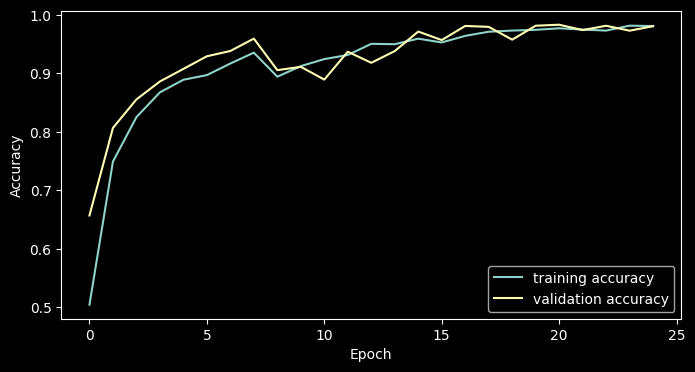

In [7]:
plt.figure(figsize=(8,4))
plt.plot(history.history["accuracy"], label="training accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

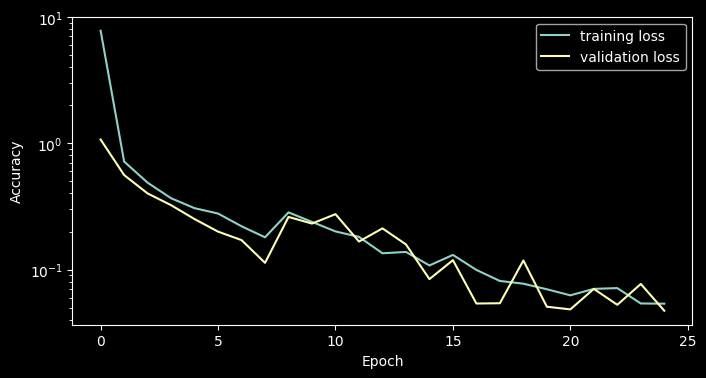

In [11]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [22]:
true = [label_names[label] for _, label in test_images.unbatch()]
pred = [label_names[label] for label in model.predict(test_images).argmax(axis=1)]

confusion_matrix(
    y_true=true,
    y_pred=pred,
)

176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


ValueError: Found input variables with inconsistent numbers of samples: [5632, 5604, 5632]

In [ ]:
model.save("model.keras")